In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.radar_parser import radar9_parser, radar24_parser
from utils.get_range_FFT import get_range_FFT
from utils.range_cfar import range_cfar
from utils.get_doppler import get_doppler, plot_dopler
from utils.get_max_velocity import get_max_velocity

# Radar 9 MHz 

{'ch': np.uint16(1), 'frequ_start': 9600000000, 'frequ_stop': 10000000000, 'sweep_time': np.float64(0.004), 'NTS': 1024, 'bw': 400000000, 'fc': 9800000000.0, 'fs': np.float64(256000.0), 'num_chirps': 2500}


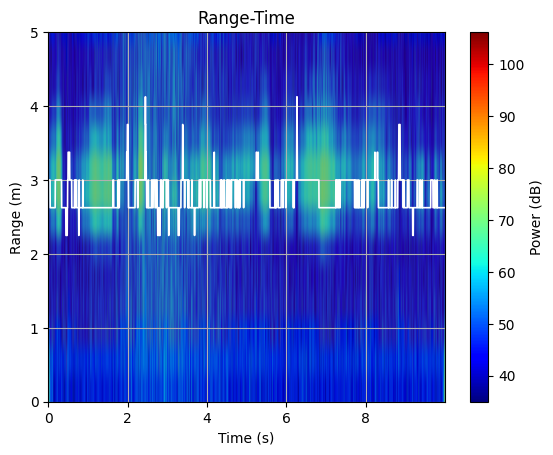

c:\Users\Kelly\akelly\ENSEA\stabilometrie\synchro_plateforme_de_force\stabilogram_extraction\scripts\utils\get_doppler.py:97: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, S = spectrogram(
c:\Users\Kelly\akelly\ENSEA\stabilometrie\synchro_plateforme_de_force\stabilogram_extraction\scripts\utils\get_doppler.py:20: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(np.abs(doppler_data)),


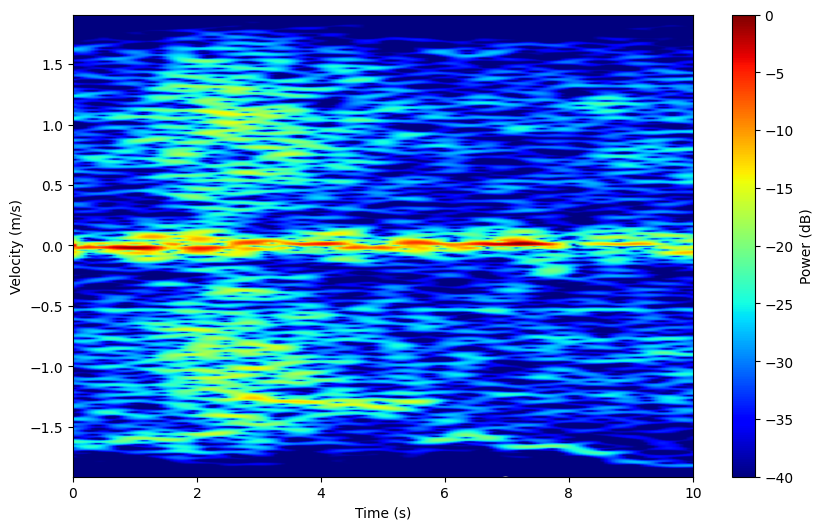

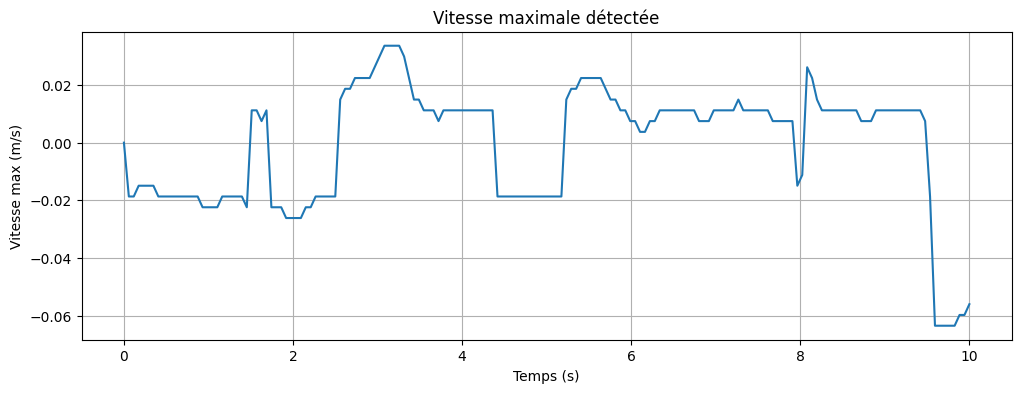

In [2]:

file = "../data/kelly/A151P148R1S5D0.bin"
RADAR_PARAM, radar_data = radar9_parser(file)
print(RADAR_PARAM)

CFAR_PARAM = {
    "min_range": 2,
    "max_range": 5,
    "train": 8,
    "guard": 4,
    "pfa": 1e-6,
    "bandhalfwidth": 0.8,
    "soft_sigma": 0.8,
    "soft_floor": 0.05
}

MIN_RANGE_FOR_DOPPLER_DETECTION = 2
MAX_RANGE_FOR_DOPPLER_DETECTION = 5

range_FFT = get_range_FFT(radar_data)
M, W, bin_indl, bin_indu = range_cfar(
    RADAR_PARAM, range_FFT,
    MIN_RANGE_FOR_DOPPLER_DETECTION, 
    MAX_RANGE_FOR_DOPPLER_DETECTION)

MD, data_spec_MTI2 = get_doppler(RADAR_PARAM, range_FFT, M, W, bin_indl, bin_indl)

plot_dopler(RADAR_PARAM, MD, data_spec_MTI2)
get_max_velocity(RADAR_PARAM, MD, data_spec_MTI2, "../data/kelly/Y_vitesse.csv")

# Radar 24 MHz 

(5120000,)
{'NTS': 1024, 'num_chirps': 2500, 'TxSelect': 'Tx1', 'RxSelect': 'Rx1', 'freq_start': 24500000000.0, 'freq_stop': 25500000000.0, 'sweep_time': 0.004, 'order': 0, 'bw': 1000000000.0, 'fc': 25000000000.0, 'fs': 625000.0}


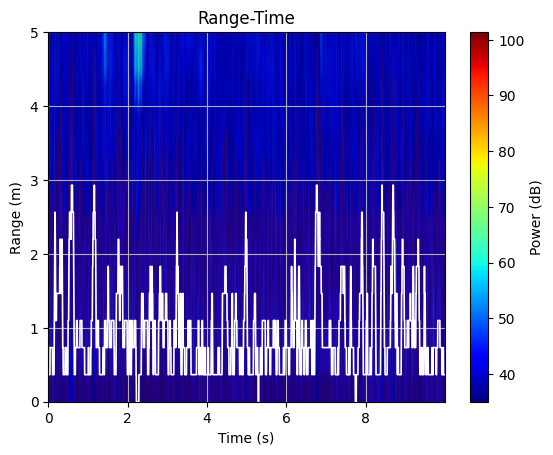

c:\Users\Kelly\akelly\ENSEA\stabilometrie\synchro_plateforme_de_force\stabilogram_extraction\scripts\utils\get_doppler.py:98: UserWarning: Input data is complex, switching to return_onesided=False
  x,
c:\Users\Kelly\akelly\ENSEA\stabilometrie\synchro_plateforme_de_force\stabilogram_extraction\scripts\utils\get_doppler.py:21: RuntimeWarning: divide by zero encountered in log10
  aspect='auto',


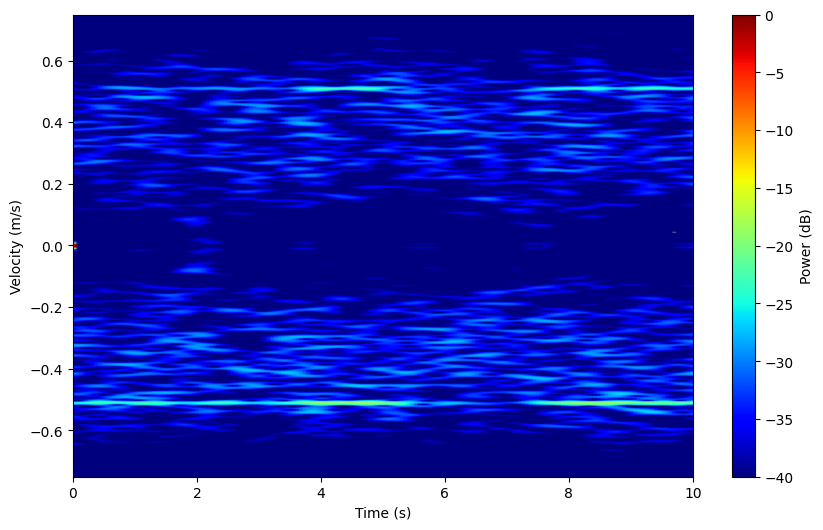

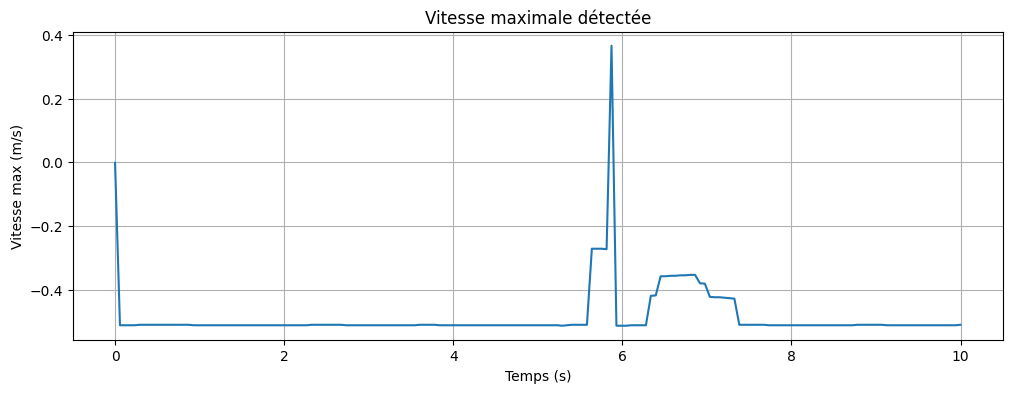

In [4]:

file = "../data/kelly/iq_tx12.bin"
RADAR_PARAM, radar_data = radar24_parser(file)
print(RADAR_PARAM)

MIN_RANGE_FOR_DOPPLER_DETECTION = 0
MAX_RANGE_FOR_DOPPLER_DETECTION = 3

range_FFT = get_range_FFT(radar_data)
M, W, bin_indl, bin_indu = range_cfar(
    RADAR_PARAM, range_FFT,
    MIN_RANGE_FOR_DOPPLER_DETECTION, 
    MAX_RANGE_FOR_DOPPLER_DETECTION)

MD, data_spec_MTI2 = get_doppler(RADAR_PARAM, range_FFT, M, W, bin_indl, bin_indl)

plot_dopler(RADAR_PARAM, MD, data_spec_MTI2)
get_max_velocity(RADAR_PARAM, MD, data_spec_MTI2, "../data/kelly/X_vitesse.csv")

In [4]:
radar_data

array([[267.74414062 -6.35922899j, 267.71875    -0.86182795j,
        265.71679688 -0.89375038j, ..., 265.77734375 -9.26192518j,
        265.76953125 -1.55477371j, 265.87304688 -1.58968386j],
       [239.74414062 -9.60677411j, 225.71875   -10.49023119j,
        225.71679688-10.94937007j, ..., 241.77734375-12.28372457j,
        223.76953125-12.04473792j, 223.87304688-12.2190839j ],
       [257.74414062-20.13512493j, 261.71875   -23.59331497j,
        261.71679688-23.6553131j , ..., 261.77734375-22.72043683j,
        263.76953125-24.35124559j, 263.87304688-24.35192758j],
       ...,
       [267.74414062-19.4200239j , 267.71875   -20.4626122j ,
        267.71679688-20.59346092j, ..., 265.77734375-21.02426929j,
        265.76953125-20.35084791j, 265.87304688-19.57757191j],
       [265.74414062-13.67258128j, 267.71875   -13.62663042j,
        267.71679688-15.68324346j, ..., 267.77734375-14.0348938j ,
        265.76953125-14.1737329j , 265.87304688-16.58413185j],
       [267.74414062-16.6554